# LDA
In this TP you are going to build the Linear Discriminant Analysis classifier, that can be also used for dimensionality reduction. 

You are going to fill a few missing functions in the python scripts to implement the exercises that we ask. So first of all read and understand the given python scripts.  To run your code you have to run the main\_lda.ipynb notebook.  

## Exersises

- Fill the missing functions in the `LDA`, `LDARaleygh` and `LDAGD` class in `lda.py, lda\_raleygh.py and lda\_gd.py to implement the the LDA algorithm.

- Use main\_lda.ipynb in order to run the functions that you implement in the `LDA`, `LDARaleygh` and `LDAGD` classes. You cannot modify the given functions.

- Write a function named `compute_accuracy(y_true, y_pred)` in the `utils.py` script. The function takes as arguments the true and the predicted class labels and returns the accuracy. Use only numpy.



- Once your implementation is ready you will work with for the following datasets:

**Datasets:**
- Iris dataset (https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset)
- Breast cancer dataset (https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset)
	



## General instruction

The code should be well written with detailed comments to explain what you do at each step.  Avoid the for loops and if statements using the nymPy library. Your code should be generic and you should use the given functions.

In [428]:
from __future__ import print_function
import numpy as np

from utils import train_test_split, compute_accuracy
# make figures appear inline
%matplotlib inline


# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

np.random.seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Breast Cancer dataset

In [429]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
X_train, y_train, X_test, y_test = train_test_split(X, y, 0.3, normalize=True)

# print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (399, 30)
Training labels shape:  (399,)
Test data shape:  (170, 30)
Test labels shape:  (170,)


## Import the LDA classifiers and start filling the missing parts.

### 1. Test LDA with Rayleigh quotient implementation

In [430]:
# import classifier 
from lda_rayleigh  import LDARayleigh

lda_clf = LDARayleigh(n_components=1)

SW, SB = lda_clf.calculate_scatter_matrices(X_train, y_train)
assert SW.shape == SB.shape == (X_train.shape[1], X_train.shape[1])

In [431]:
lda_clf._calculate_discriminants(X_train, y_train)
assert lda_clf.linear_discriminants is not None
assert lda_clf.linear_discriminants.shape == (X_train.shape[1], lda_clf.n_components)

In [432]:
lda_clf.train(X_train, y_train)

In [433]:
y_pred = lda_clf.predict(X_test)
assert y_pred.shape == y_test.shape

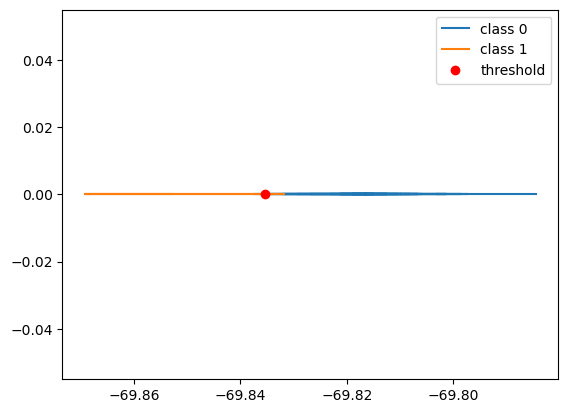

In [434]:
lda_clf.plot_1d(X_test, y_test)

### 2. Test Gradient Descent implementation

Before the tests and the code, I want to explain what is this technique and how it works.

The Linear Discriminant method is a way to classify two classes $c_1$ and $c_2$:

We have two classes and we want to class elements which are not classed.
To do that, we want to find an optimal transformation to map all the elements of the classes on just one line, and separe then thanks to a threshold which split the two classes.

So we have a dataset $X$ of dimensions $(n, d)$ ($n$: number of lines, $d$: number of features)

We want to find an optimal $w$ (of dimension $(d, h)$, with $h = \text{number of classes} - 1$) to map all the datas on one line. The $w$ is optimal if the classes are well separated.

To map the datas on the line, we apply $X \cdot w$, and then we have only a dataset of dimension $n, h$.

And then, we just have to find a threshold to separe classes.

So we want to find an optimal $w$ to map our dataset.

We note $\bar{x}$ the data $x$ projected and $\bar{\mu}$ the mean of the $\bar{x}$

We want to maximise the distance between the mean of the classes, so we have:

$$
\begin{align}
\sum_i^h (\bar{\mu_i} - \bar{\mu_{i + 1}})^2
&= \sum_i^h \left(\frac{1}{n_i}\sum_{x \in c_i} w^Tx - \frac{1}{n_{i + 1}}\sum_{y \in c_{i + 1}} w^Ty \right)^2 \\
&= \sum_i^h \left(w^T\mu_i - w^T\mu_{i + 1} \right)^2 \\
&= \sum_i^h \left(w^T(\mu_i -\mu_{i + 1}) \right)^2 \\
&= \sum_i^h \left(w^T(\mu_i -\mu_{i + 1})(\mu_i -\mu_{i + 1})^Tw\right) \\
&= w^T\left(\sum_i^h(\mu_i -\mu_{i + 1})(\mu_i -\mu_{i + 1})^T\right)w \\
&= w^TS_Bw \\
\end{align}
$$

$S_B$ is called the between class scatter matrix.

But we want that the variance is not too big, to avoid overlaps of the classes.

So we want that:

$$
\begin{align}
\sum_i^{h + 1} \sum_{x \in c_i} \left( \bar{x} - \bar{\mu_i}\right)^2
&=\sum_i^{h + 1} \sum_{x \in c_i} \left( w^Tx - w^T\mu_i\right)^2 \\
&= \sum_i^{h + 1} \sum_{x \in c_i} \left( w^T(x - \mu_i)\right)^2 \\
&= \sum_i^{h + 1} \sum_{x \in c_i} w^T(x - \mu_i)(x - \mu_i)^T w \\
&= w^T \left(\sum_i^{h + 1} \sum_{x \in c_i}(x - \mu_i)(x - \mu_i)^T \right) w \\
&= w^T S_w w \\
\end{align}
$$

$S_w$ is called the within class scatter matrix.

So we want to find a $w$ that minimise the within class and maximise the between class.

That's why we define the Fisher linear discriminant $J(w) = \frac{|w^T S_B w|}{|w^T S_w w|}$
and we want to find a $w$ that maximise this Fisher linear discriminant.

As we want to find the $w$ which maximise the Fisher linear discriminant, we can define $\hat{J} = J^{-1} = \frac{|w^T S_w w|}{|w^T S_B w|}$. And then, as it's a minimisation problem, we can use the gradient descent, so we have $w^{j + 1} = w^{j} - \alpha \frac{\partial \hat{J}}{\partial w}$.

The gradient of $\hat{J}$ is given by:

$$\frac{\partial \hat{J}}{\partial w} = 2\hat{J}(w) [ S_w w (w^TS_w w)^{-1} - S_B w (w^T S_B w)^{-1}]$$

In [435]:
from lda_gd import LDAGD

In [436]:
lda_clf = LDAGD(n_components=1)

In [437]:
SW, SB = lda_clf.calculate_scatter_matrices(X_train, y_train)
assert SW.shape == SB.shape == (X_train.shape[1], X_train.shape[1])

In [438]:
lda_clf._calculate_discriminants(X_train, y_train)
assert lda_clf.linear_discriminants is not None
assert lda_clf.linear_discriminants.shape == (X_train.shape[1], lda_clf.n_components)

In [439]:

lda_clf.train(X_train, y_train)

In [440]:
y_pred = lda_clf.predict(X_test)
assert y_pred.shape == y_test.shape

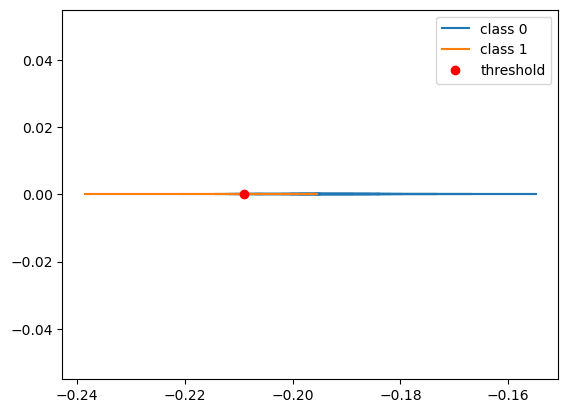

In [441]:
lda_clf.plot_1d(X_test, y_test)

### Once your implementation is ready run the both classifiers and compute the classification accuracy for breast cancer dataset.

#### (You have to fill  the compute_accuracy() function in the utils.py script)






-------------------------------------------------------------------------------------------------------------------

### Run the LDARayleigh and LDAGD classifiers using on the Breast Cancer dataset and compute classification accuracy on both training and test set.

In [442]:
from utils import compute_accuracy

## Iris dataset

In [443]:
# Cleaning up variables to prevent loading data multiple times (which may cause memory issues)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

Clear previously loaded data.


In [444]:
# Loas the breast cancer data set
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
X_train, y_train, X_test, y_test = train_test_split(X, y, 0.3, normalize=True)

In [445]:
# import classifier 
from lda_rayleigh import LDARayleigh
lda_clf = LDARayleigh(n_components=1)
lda_clf.train(X_train, y_train)
y_pred_train = lda_clf.predict(X_train)
y_pred_test = lda_clf.predict(X_test)
train_accuracy = compute_accuracy(y_train, y_pred_train)
test_accuracy = compute_accuracy(y_test, y_pred_test)

print(f"LDA_Rayleigh train accuracy: {train_accuracy}")
print(f"LDA_Rayleigh test accuracy: {test_accuracy}")

LDA_Rayleigh train accuracy: 0.9699248120300752
LDA_Rayleigh test accuracy: 0.9764705882352941


In [446]:
# import classifier 
from lda_gd  import LDAGD
lda_clf = LDAGD(n_components=1)
lda_clf.train(X_train, y_train)
y_pred_train = lda_clf.predict(X_train)
y_pred_test = lda_clf.predict(X_test)
train_accuracy = compute_accuracy(y_train, y_pred_train)
test_accuracy = compute_accuracy(y_test, y_pred_test)

print(f"LDA_GD train accuracy: {train_accuracy}")
print(f"LDA_GD test accuracy: {test_accuracy}")

LDA_GD train accuracy: 0.8696741854636592
LDA_GD test accuracy: 0.9


### LDA for dimensionality reduction.

Similarly to PCA, LDA can  can also be used as a dimensionality reduction technique. 
In fact, LDA provides a projection of the data points in a lower dimension that best separates the examples by their assigned class.

In [453]:
from utils import load_IRIS
X_train, y_train, X_test, y_test = load_IRIS(test=True)

# print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)              

Training data shape:  (100, 4)
Training labels shape:  (100,)
Test data shape:  (50, 4)
Test labels shape:  (50,)


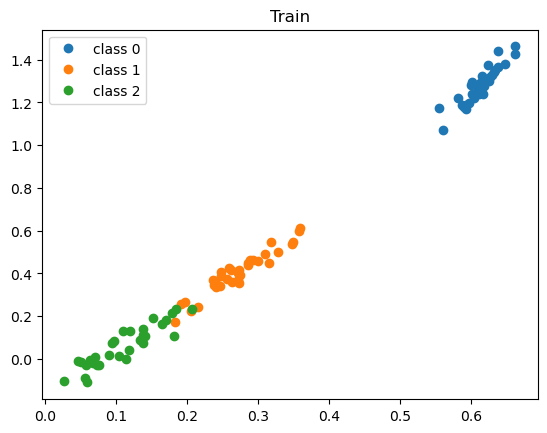

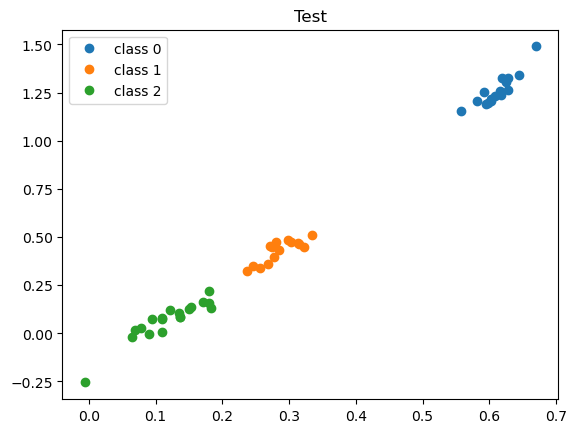

In [456]:
lda_clf = LDARayleigh(n_components=2)
SW, SB = lda_clf.calculate_scatter_matrices(X_train, y_train)
lda_clf.train(X_train, y_train)
lda_clf.plot_2d(X_train, y_train, "Train")
lda_clf.plot_2d(X_test, y_test, "Test")

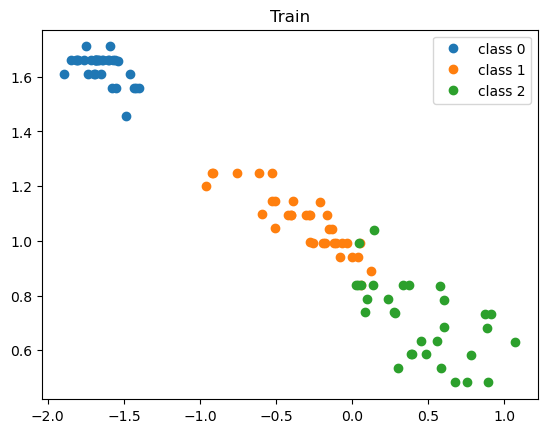

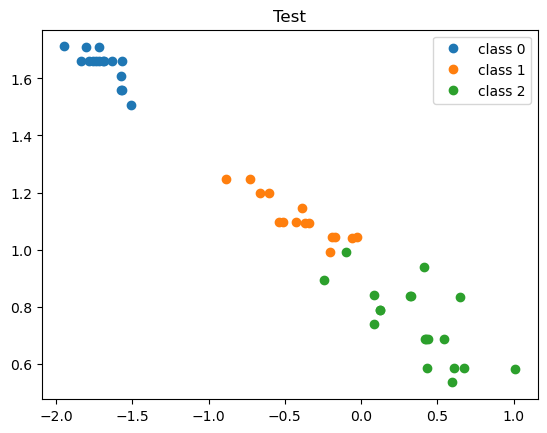

In [455]:
lda_clf = LDAGD(n_components=2)
lda_clf.train(X_train, y_train)
lda_clf.plot_2d(X_train, y_train, "Train")
lda_clf.plot_2d(X_test, y_test, "Test")

-------------------------------------------------------------------------------------------------------------------

There is something I don't understand in this project: with the gradient descent, I have always the class 1 before the class 0. So I have inverted the order of the classes (they are sorted in inverse mode) to have class 1 before class 0 in raleigh method. And in prediction, I have to invert the prediction: $x < \text{threshold} \rightarrow 1$ and $x \geq \text{threshold} \rightarrow 0$